# Fake image detection classifier
- **Classifier labels**: 1 for fake and 0 for real

In [77]:
import os
import numpy as np
from PIL import Image
from sklearn.model_selection import train_test_split
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import pandas as pd
from collections import Counter
import matplotlib.pyplot as plt

In [78]:
# Constants
DATA_DIR = 'data'
SAVE_PATH = 'preprocessed_data.npz'
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
IMG_SIZE = (64, 64)
IMG_DIR_NAMES = ['wiki', 'inpainting', 'insight', 'text2img']
REAL_IMG_DIR = 'wiki'

In [79]:
# If the image is not from the real dataset, it is fake
# 1: fake, 0: real
def isImgFake(img_main_dir):
    return int(img_main_dir != REAL_IMG_DIR)

In [80]:
# Check if CUDA is available with PyTorch
print("Checking for available hardware...")
print('Using DEVICE:', DEVICE)
if DEVICE.type == 'cuda':
    print(f"CUDA Device: {torch.cuda.get_device_name(0)}")
    print(f"CUDA Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB")
else:
    print("No GPU found, using CPU instead")

Checking for available hardware...
Using DEVICE: cuda
CUDA Device: NVIDIA GeForce RTX 4070 Ti SUPER
CUDA Memory: 17.17 GB


In [81]:
# Loading of the images and preprocessing
def load_and_preprocess_images(data_dir, img_size, save_path):
    """
    Loads and preprocesses images from the specified directory.
    Saves the preprocessed data to a file to avoid reprocessing.
    """
    # Check if preprocessed data already exists
    if os.path.exists(save_path):
        print(f"Loading preprocessed data from {save_path}...")
        data = np.load(save_path)
        return data['X'], data['y']
    
    print(f"Loading and preprocessing images from {data_dir}...")
    X = []
    y = []
    
    for index, main_folder in enumerate(IMG_DIR_NAMES):
        main_folder_path = os.path.join(data_dir, main_folder)
        print(f"Processing directory {main_folder}...")
        image_count = 0
        for subfolder_name in os.listdir(main_folder_path):
            subfolder_path = os.path.join(main_folder_path, subfolder_name)
            if os.path.isdir(subfolder_path):
                for filename in os.listdir(subfolder_path):
                    if filename.endswith('.jpg'):
                        img_path = os.path.join(subfolder_path, filename)
                        try:
                            img = Image.open(img_path).convert('RGB')  # Ensure RGB format
                            img = img.resize(img_size)
                            img_array = np.array(img) / 255.0
                            X.append(img_array)
                            y.append(isImgFake(main_folder))  # 1 for other, 0 for wiki
                            image_count += 1
                        except Exception as e:
                            print(f"Error processing {img_path}: {e}")
                    else:
                        print(f"Skipping non jpg file: {filename}")
                        
        print(f"  - Loaded {image_count} images for category {main_folder}")

    print(f"Total images loaded: {len(X)}")
    
    # Convert to numpy arrays
    X = np.array(X)
    y = np.array(y)
    
    print(X)
    print(y)
    
    # Save preprocessed data
    print(f"Saving preprocessed data to {save_path}...")
    np.savez(save_path, X=X, y=y)
    
    return X, y

In [82]:
# Define a Complex CNN
class ComplexCNN(nn.Module):
    def __init__(self, num_classes=4):
        super(ComplexCNN, self).__init__()

        self.features = nn.Sequential(
            # The number of filters (output channels) increases in each subsequent convolutional block (32 -> 64 -> 128 ->256).  This allows the network to learn increasingly complex and abstract features.

            # Block 1: Increase depth, add Batch Norm and Dropout
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),  # Batch Normalization
            nn.ReLU(inplace=True),
            nn.Conv2d(32, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),
            nn.Dropout2d(0.25),  # Dropout

            # Block 2:  Increase depth further, add Batch Norm and Dropout
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.Conv2d(64, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),
            nn.Dropout2d(0.28),

            # Block 3:  Increase depth and complexity, add Batch Norm and Dropout
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.Conv2d(128, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),
            nn.Dropout2d(0.3), # Increased dropout slightly

             # Block 4:  Further Increase Depth
            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),
            nn.Conv2d(256, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),
            nn.Dropout2d(0.32), # Increased dropout slightly
        )

        # Calculate the correct input size for the fully connected layers.
        # With 64x64 input and four 2x2 max pooling operations:
        # 64 / 2 / 2 / 2 / 2 = 4
        self.classifier = nn.Sequential(
            # The classifier part of the network now has two fully connected layers (nn.Linear) instead of one.  
            # This increases the model's capacity to learn non-linear relationships between the features extracted by the convolutional layers and the output classes.  
            # Batch normalization and dropout are also applied to the fully connected layers.
            nn.Flatten(),
            nn.Linear(256 * 4 * 4, 1024),  # Increased hidden units
            nn.BatchNorm1d(1024), # Batch Normalization for 1D layers
            nn.ReLU(inplace=True),
            nn.Dropout(0.5),  # Dropout for fully connected layers
            nn.Linear(1024, 512), # Added another fully connected layer
            nn.BatchNorm1d(512),
            nn.ReLU(inplace = True),
            nn.Dropout(0.5),
            nn.Linear(512, num_classes),  # Output layer
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

In [83]:
# Define a simple CNN model
class SimpleCNN(nn.Module):
    def __init__(self):
        super(SimpleCNN, self).__init__()
        self.conv1 = nn.Conv2d(3, 32, kernel_size=3, stride=1, padding=1)
        self.relu = nn.ReLU()
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, stride=1, padding=1)
        self.fc1 = nn.Linear(64 * 16 * 16, 128)  # Adjusted for 64x64 input
        self.fc2 = nn.Linear(128, 1)  # Binary classification

    def forward(self, x):
        x = self.pool(self.relu(self.conv1(x)))
        x = self.pool(self.relu(self.conv2(x)))
        x = x.view(x.size(0), -1)  # Flatten
        x = self.relu(self.fc1(x))
        x = self.fc2(x)
        return x

In [84]:
print("\n--- Starting Image Classification ---")

# Load and preprocess data
X, y = load_and_preprocess_images(DATA_DIR, IMG_SIZE, SAVE_PATH)

# Split the data
print("\nSplitting data into training and testing sets (80/20)...")
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
X_train = torch.tensor(X_train, dtype=torch.float32).permute(0, 3, 1, 2)  # Change shape to [batch, channels, height, width]
X_test = torch.tensor(X_test, dtype=torch.float32).permute(0, 3, 1, 2)
y_train = torch.tensor(y_train, dtype=torch.float32).view(-1, 1)  # Reshape for BCE loss
y_test = torch.tensor(y_test, dtype=torch.float32).view(-1, 1)


--- Starting Image Classification ---
Loading preprocessed data from preprocessed_data.npz...

Splitting data into training and testing sets (80/20)...


   image_index  label label_name
0            0      0       Real
1            1      0       Real
2            2      0       Real
3            3      0       Real
4            4      0       Real

Label distribution:
label_name
Fake    90000
Real    30000
Name: count, dtype: int64


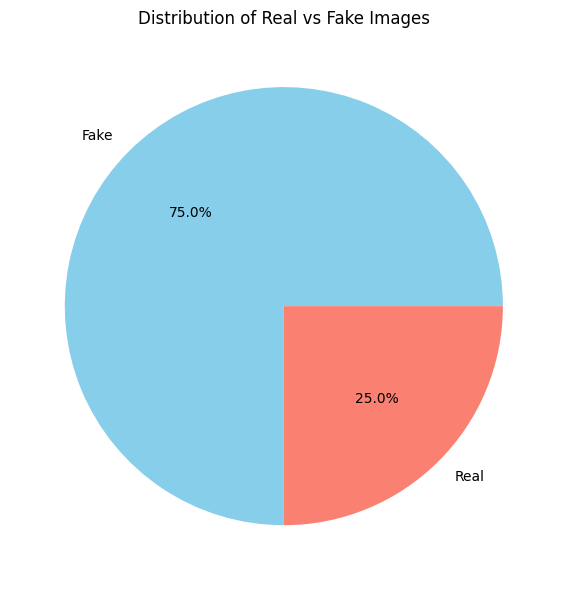

In [85]:
# Create a DataFrame with image indices and their corresponding labels
df_classification = pd.DataFrame({
    'image_index': range(len(y)),
    'label': y
})

# Convert binary labels to descriptive labels
df_classification['label_name'] = df_classification['label'].apply(lambda x: 'Fake' if x == 1 else 'Real')

# Display the first few rows of the DataFrame
print(df_classification.head())

# Display some summary statistics
print("\nLabel distribution:")
print(df_classification['label_name'].value_counts())

# Optional: Create a pie chart visualization of the label distribution
plt.figure(figsize=(8, 6))
df_classification['label_name'].value_counts().plot.pie(autopct='%1.1f%%', colors=['skyblue', 'salmon'])
plt.title('Distribution of Real vs Fake Images')
plt.ylabel('')  # Hide the y-label
plt.tight_layout()
plt.show()

In [93]:
from sklearn.metrics import confusion_matrix, classification_report

# Create DataLoaders
batch_size = 32
train_dataset = TensorDataset(X_train, y_train)
test_dataset = TensorDataset(X_test, y_test)
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

# Calculate the weights to use the BCEWithLogitsLoss with class imbalance
# Calculate class weights for handling imbalance
class_counts = torch.bincount(y_train.long().view(-1))
num_real = class_counts[0].item()  # Count of real images (label 0)
num_fake = class_counts[1].item()  # Count of fake images (label 1)
# weight_for_real = len(y_train) / (num_real * 2)
# weight_for_fake = len(y_train) / (num_fake * 2)
print(f"Class distribution - Real: {num_real}, Fake: {num_fake}")
# print(f"Class weights - Real: {weight_for_real:.4f}, Fake: {weight_for_fake:.4f}")

pos_weight = torch.tensor(num_real / num_fake).to(DEVICE)

# Initialize model
model = SimpleCNN().to(DEVICE)

# Use BCEWithLogitsLoss for binary classification with class weights
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight).to(DEVICE)

# Define the optimizer
optimizer = optim.Adam(model.parameters(), lr=0.001)

# Training loop
num_epochs = 150
print("\n--- Starting Training ---")
for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0
    for images, labels in train_loader:
        images, labels = images.to(DEVICE), labels.to(DEVICE, dtype=torch.float32)  # Ensure labels are float for BCEWithLogitsLoss

        optimizer.zero_grad()
        outputs = model(images)  # Raw logits from the model

        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
    
    print(f"Epoch [{epoch+1}/{num_epochs}], Loss: {running_loss/len(train_loader):.4f}")

print("\n--- Training Complete ---")

Class distribution - Real: 23921, Fake: 72079

--- Starting Training ---
Epoch [1/150], Loss: 0.3228
Epoch [2/150], Loss: 0.3107
Epoch [3/150], Loss: 0.3043
Epoch [4/150], Loss: 0.2998
Epoch [5/150], Loss: 0.2955
Epoch [6/150], Loss: 0.2924
Epoch [7/150], Loss: 0.2890
Epoch [8/150], Loss: 0.2861
Epoch [9/150], Loss: 0.2829
Epoch [10/150], Loss: 0.2805
Epoch [11/150], Loss: 0.2776
Epoch [12/150], Loss: 0.2745
Epoch [13/150], Loss: 0.2718
Epoch [14/150], Loss: 0.2695
Epoch [15/150], Loss: 0.2670
Epoch [16/150], Loss: 0.2645
Epoch [17/150], Loss: 0.2623
Epoch [18/150], Loss: 0.2595
Epoch [19/150], Loss: 0.2592
Epoch [20/150], Loss: 0.2553
Epoch [21/150], Loss: 0.2537
Epoch [22/150], Loss: 0.2521
Epoch [23/150], Loss: 0.2506
Epoch [24/150], Loss: 0.2476
Epoch [25/150], Loss: 0.2461
Epoch [26/150], Loss: 0.2446
Epoch [27/150], Loss: 0.2420
Epoch [28/150], Loss: 0.2423
Epoch [29/150], Loss: 0.2387
Epoch [30/150], Loss: 0.2381
Epoch [31/150], Loss: 0.2365
Epoch [32/150], Loss: 0.2342
Epoch [3

In [ ]:
# import torch
# import torch.nn as nn
# import torchvision.models as models

# # Load DenseNet201 with pretrained weights
# densenet = models.densenet201(weights=models.DenseNet201_Weights.DEFAULT)

# # Modify the classifier for binary classification (Real vs. Fake)
# num_ftrs = densenet.classifier.in_features  # Get the input features of the last layer
# densenet.classifier = nn.Sequential(
#     nn.Linear(num_ftrs, 1),  # Single output neuron for binary classification
#     nn.Sigmoid()  # Sigmoid to get probabilities
# )

# # Move model to GPU if available
# DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
# densenet = densenet.to(DEVICE)


--- Starting Evaluation ---
tensor([[-8.9398e-01],
        [-1.3268e+00],
        [ 8.3625e-01],
        [-1.4720e+00],
        [ 3.1011e+00],
        [ 6.7065e+01],
        [ 3.0768e+00],
        [ 6.2136e-01],
        [ 7.0092e-01],
        [ 6.3605e+01],
        [ 1.0609e+00],
        [-1.5218e+00],
        [ 8.6325e+01],
        [ 3.4135e-01],
        [-1.0216e+00],
        [ 4.1993e-01],
        [-4.7317e-01],
        [-1.5125e+00],
        [-6.3022e-01],
        [ 3.0472e-03],
        [-2.8424e-01],
        [-5.2782e+00],
        [-1.1781e+00],
        [ 1.6750e+01],
        [ 3.9293e-01],
        [-6.2246e-01],
        [-5.1175e+00],
        [ 4.6631e+00],
        [-2.4097e+00],
        [ 4.2638e-01],
        [ 3.1998e+02],
        [-1.3265e-02]], device='cuda:0')
tensor([[ 1.1906e+02],
        [ 9.3253e-01],
        [ 1.4335e+01],
        [-6.6159e-01],
        [-4.2600e+00],
        [ 3.2483e-01],
        [ 1.1434e-01],
        [ 1.1959e+02],
        [-6.7991e+00],
        [ 

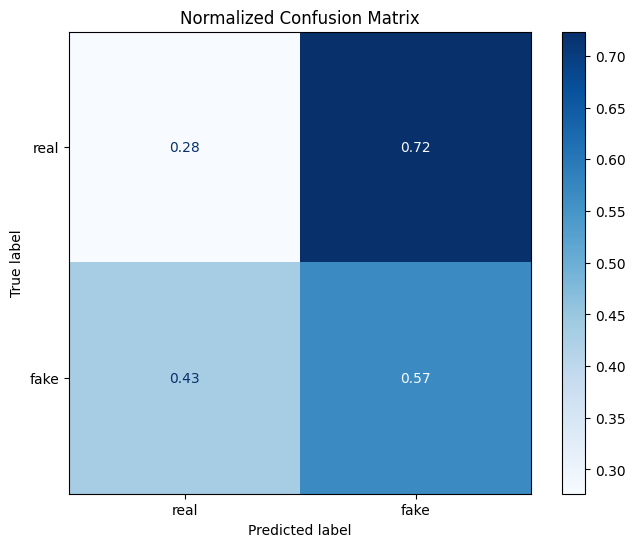


--- Classification Complete ---


In [95]:
print("\n--- Starting Evaluation ---")
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

model.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for inputs, labels in test_loader:
        inputs, labels = inputs.to(DEVICE), labels.to(DEVICE, dtype=torch.float32)

        outputs = model(inputs)
        print(outputs)

        # Apply sigmoid if using BCEWithLogitsLoss
        if isinstance(criterion, nn.BCEWithLogitsLoss):
            outputs = torch.sigmoid(outputs)

        # Convert probabilities to binary predictions (threshold at 0.5)
        predicted = (outputs >= 0.5).float()

        # Store predictions and labels
        all_preds.extend(predicted.cpu().numpy().flatten())  # Flatten to 1D list
        all_labels.extend(labels.cpu().numpy().flatten())    # Flatten to 1D list

# Convert lists to NumPy arrays for evaluation
all_preds = np.array(all_preds, dtype=int)
all_labels = np.array(all_labels, dtype=int)

# Display predictions and labels
print("\nSample Predictions:")
print(f"True Labels   : {all_labels[:20]}")
print(f"Predicted     : {all_preds[:20]}")

# Generate classification report
print("\nClassification Report:")
print(classification_report(all_labels, all_preds, target_names=['real', 'fake']))

# Plot confusion matrix
cm = confusion_matrix(all_labels, all_preds, normalize='true')
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['real', 'fake'])

fig, ax = plt.subplots(figsize=(8, 6))
disp.plot(ax=ax, cmap='Blues', values_format=".2f")
plt.title('Normalized Confusion Matrix')
plt.savefig('confusion_matrix.png')
plt.show()

print("\n--- Classification Complete ---")